<a href="https://colab.research.google.com/github/AdriBell01/context-sensitive-design-of-a-medical-device-/blob/main/dataugumentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
!pip install librosa scikit-learn tensorflow tqdm matplotlib numpy pandas -q

import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import pickle
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers

print("TensorFlow version:", tf.__version__)
print("Setup completato.")

TensorFlow version: 2.20.0
Setup completato.


In [8]:
# =====================================================================
# CELLA 2 — Generatori PCG sintetici
# Le 3 classi sono acusticamente molto diverse:
#
# Normal:      S1 forte (0.9) + S2 forte (0.8) + NESSUN soffio
#              rumore molto basso
#
# Subclinical: S1 ridotto (0.5) + soffio LIEVE protomesosistolico
#              solo prima metà sistole, frequenza bassa (80-150 Hz)
#
# Advanced:    S1 quasi assente (0.15) + soffio SEVERO olosistolico
#              tutta la sistole, frequenza alta (200-500 Hz)
#              + componente diastolica residua
# =====================================================================

SR         = 4000
N_MELS     = 40
N_FFT      = 512
HOP_LENGTH = 128
SG_MAXLEN  = 128


def make_envelope(n, ramp_frac=0.1):
    """Envelope trapezoidale con rampe smussate."""
    env  = np.ones(n)
    ramp = max(2, int(n * ramp_frac))
    env[:ramp]  = np.linspace(0, 1, ramp)
    env[-ramp:] = np.linspace(1, 0, ramp)
    return env


def generate_normal_pcg(sr=SR, duration=3.0, heart_rate=85,
                         noise_level=0.01, seed=None):
    if seed is not None:
        np.random.seed(seed)
    n   = int(sr * duration)
    t   = np.linspace(0, duration, n)
    sig = np.zeros(n)
    rr  = 60.0 / heart_rate

    for bt in np.arange(0, duration - rr * 0.1, rr):
        # S1 — forte e netto (due componenti frequenziali)
        for f, amp in [(60, 0.9), (90, 0.5)]:
            d    = 0.10
            mask = (t >= bt) & (t < bt + d)
            if mask.sum() > 0:
                env = np.exp(-6 * ((t[mask] - bt) / d) ** 2)
                sig[mask] += amp * env * np.sin(2*np.pi*f*t[mask])

        # S2 — forte
        s2 = bt + rr * 0.42
        for f, amp in [(80, 0.8), (120, 0.4)]:
            d    = 0.08
            mask = (t >= s2) & (t < s2 + d)
            if mask.sum() > 0:
                env = np.exp(-6 * ((t[mask] - s2) / d) ** 2)
                sig[mask] += amp * env * np.sin(2*np.pi*f*t[mask])

    sig += noise_level * np.random.randn(n)
    return (sig / (np.max(np.abs(sig)) + 1e-8)).astype(np.float32)


def generate_subclinical_pcg(sr=SR, duration=3.0, heart_rate=90,
                              seed=None):
    if seed is not None:
        np.random.seed(seed)
    n   = int(sr * duration)
    t   = np.linspace(0, duration, n)
    sig = np.zeros(n)
    rr  = 60.0 / heart_rate

    murmur_intensity = np.random.uniform(0.15, 0.25)
    murmur_freq      = np.random.uniform(80, 150)
    noise_level      = np.random.uniform(0.02, 0.04)

    for bt in np.arange(0, duration - rr * 0.1, rr):
        # S1 — moderatamente ridotto
        for f, amp in [(60, 0.5), (90, 0.25)]:
            d    = 0.10
            mask = (t >= bt) & (t < bt + d)
            if mask.sum() > 0:
                env = np.exp(-6 * ((t[mask] - bt) / d) ** 2)
                sig[mask] += amp * env * np.sin(2*np.pi*f*t[mask])

        # Soffio protomesosistolico lieve (prima metà sistole)
        mur_s = bt + 0.03
        mur_e = bt + rr * 0.22
        mask  = (t >= mur_s) & (t < mur_e)
        if mask.sum() > 0:
            nm  = mask.sum()
            env = make_envelope(nm, ramp_frac=0.15)
            sig[mask] += murmur_intensity * env * \
                         np.sin(2*np.pi*murmur_freq*t[mask])

        # S2 — preservato
        s2 = bt + rr * 0.42
        for f, amp in [(80, 0.8), (120, 0.4)]:
            d    = 0.08
            mask = (t >= s2) & (t < s2 + d)
            if mask.sum() > 0:
                env = np.exp(-6 * ((t[mask] - s2) / d) ** 2)
                sig[mask] += amp * env * np.sin(2*np.pi*f*t[mask])

    sig += noise_level * np.random.randn(n)
    return (sig / (np.max(np.abs(sig)) + 1e-8)).astype(np.float32)


def generate_advanced_pcg(sr=SR, duration=3.0, heart_rate=95,
                           seed=None):
    if seed is not None:
        np.random.seed(seed)
    n   = int(sr * duration)
    t   = np.linspace(0, duration, n)
    sig = np.zeros(n)
    rr  = 60.0 / heart_rate

    murmur_intensity = np.random.uniform(0.60, 0.80)
    murmur_freq      = np.random.uniform(200, 500)
    noise_level      = np.random.uniform(0.03, 0.06)

    for bt in np.arange(0, duration - rr * 0.1, rr):
        # S1 — quasi assente
        for f, amp in [(60, 0.15), (90, 0.08)]:
            d    = 0.10
            mask = (t >= bt) & (t < bt + d)
            if mask.sum() > 0:
                env = np.exp(-6 * ((t[mask] - bt) / d) ** 2)
                sig[mask] += amp * env * np.sin(2*np.pi*f*t[mask])

        # Soffio olosistolico severo (90% della sistole)
        mur_s = bt + 0.01
        mur_e = bt + rr * 0.40
        mask  = (t >= mur_s) & (t < mur_e)
        if mask.sum() > 0:
            nm        = mask.sum()
            env       = make_envelope(nm, ramp_frac=0.05)
            broadband = np.random.randn(nm) * 0.5
            tonal     = np.sin(2*np.pi*murmur_freq*t[mask]) * 0.5
            sig[mask] += murmur_intensity * env * (broadband + tonal)

        # Componente diastolica residua
        diast_s = bt + rr * 0.48
        diast_e = bt + rr * 0.65
        mask    = (t >= diast_s) & (t < diast_e)
        if mask.sum() > 0:
            nm  = mask.sum()
            env = make_envelope(nm, ramp_frac=0.2)
            sig[mask] += 0.15 * env * np.random.randn(nm)

        # S2 — preservato
        s2 = bt + rr * 0.42
        for f, amp in [(80, 0.8), (120, 0.4)]:
            d    = 0.08
            mask = (t >= s2) & (t < s2 + d)
            if mask.sum() > 0:
                env = np.exp(-6 * ((t[mask] - s2) / d) ** 2)
                sig[mask] += amp * env * np.sin(2*np.pi*f*t[mask])

    sig += noise_level * np.random.randn(n)
    return (sig / (np.max(np.abs(sig)) + 1e-8)).astype(np.float32)

In [9]:
# =====================================================================
# CELLA 3 — Feature extraction e data augmentation
# =====================================================================

def pcg_to_melspec(signal, sr=SR, n_mels=N_MELS, n_fft=N_FFT,
                   hop_length=HOP_LENGTH, sg_maxlen=SG_MAXLEN):
    S    = librosa.feature.melspectrogram(
               y=signal, sr=sr, n_mels=n_mels,
               n_fft=n_fft, hop_length=hop_length)
    S_dB = librosa.power_to_db(S, ref=np.max)
    if S_dB.shape[1] < sg_maxlen:
        pad  = sg_maxlen - S_dB.shape[1]
        S_dB = np.pad(S_dB, ((0,0),(0,pad)),
                      mode='constant', constant_values=S_dB.min())
    else:
        S_dB = S_dB[:, :sg_maxlen]
    return S_dB.astype(np.float32)


def augment_spectrogram(sg):
    """
    Augmentation sullo spettrogramma:
    - Time masking: maschera fino al 15% dei frame
    - Frequency masking: maschera fino al 10% delle bande Mel
    - Gaussian noise leggero
    - Shift temporale casuale ±10%
    """
    sg     = sg.copy()
    n_mels, n_frames = sg.shape

    # Time masking
    t_mask = int(np.random.uniform(0, 0.15) * n_frames)
    if t_mask > 0:
        t_start = np.random.randint(0, max(1, n_frames - t_mask))
        sg[:, t_start:t_start + t_mask] = sg.min()

    # Frequency masking
    f_mask = int(np.random.uniform(0, 0.10) * n_mels)
    if f_mask > 0:
        f_start = np.random.randint(0, max(1, n_mels - f_mask))
        sg[f_start:f_start + f_mask, :] = sg.min()

    # Gaussian noise leggero
    sg += np.random.randn(*sg.shape) * 0.5

    # Shift temporale
    shift = int(np.random.uniform(-0.10, 0.10) * n_frames)
    sg    = np.roll(sg, shift, axis=1)

    return sg.astype(np.float32)

Generazione classe 0 (Normal)...


100%|██████████| 500/500 [00:43<00:00, 11.58it/s]


Generazione classe 1 (Subclinical RHD)...


100%|██████████| 500/500 [00:12<00:00, 41.14it/s]


Generazione classe 2 (Advanced RHD)...


100%|██████████| 500/500 [00:09<00:00, 52.70it/s] 



Dataset completo — shape: (6000, 40, 128)
  Classe 0 (Normal): 2000 campioni
  Classe 1 (Subclinical RHD): 2000 campioni
  Classe 2 (Advanced RHD): 2000 campioni


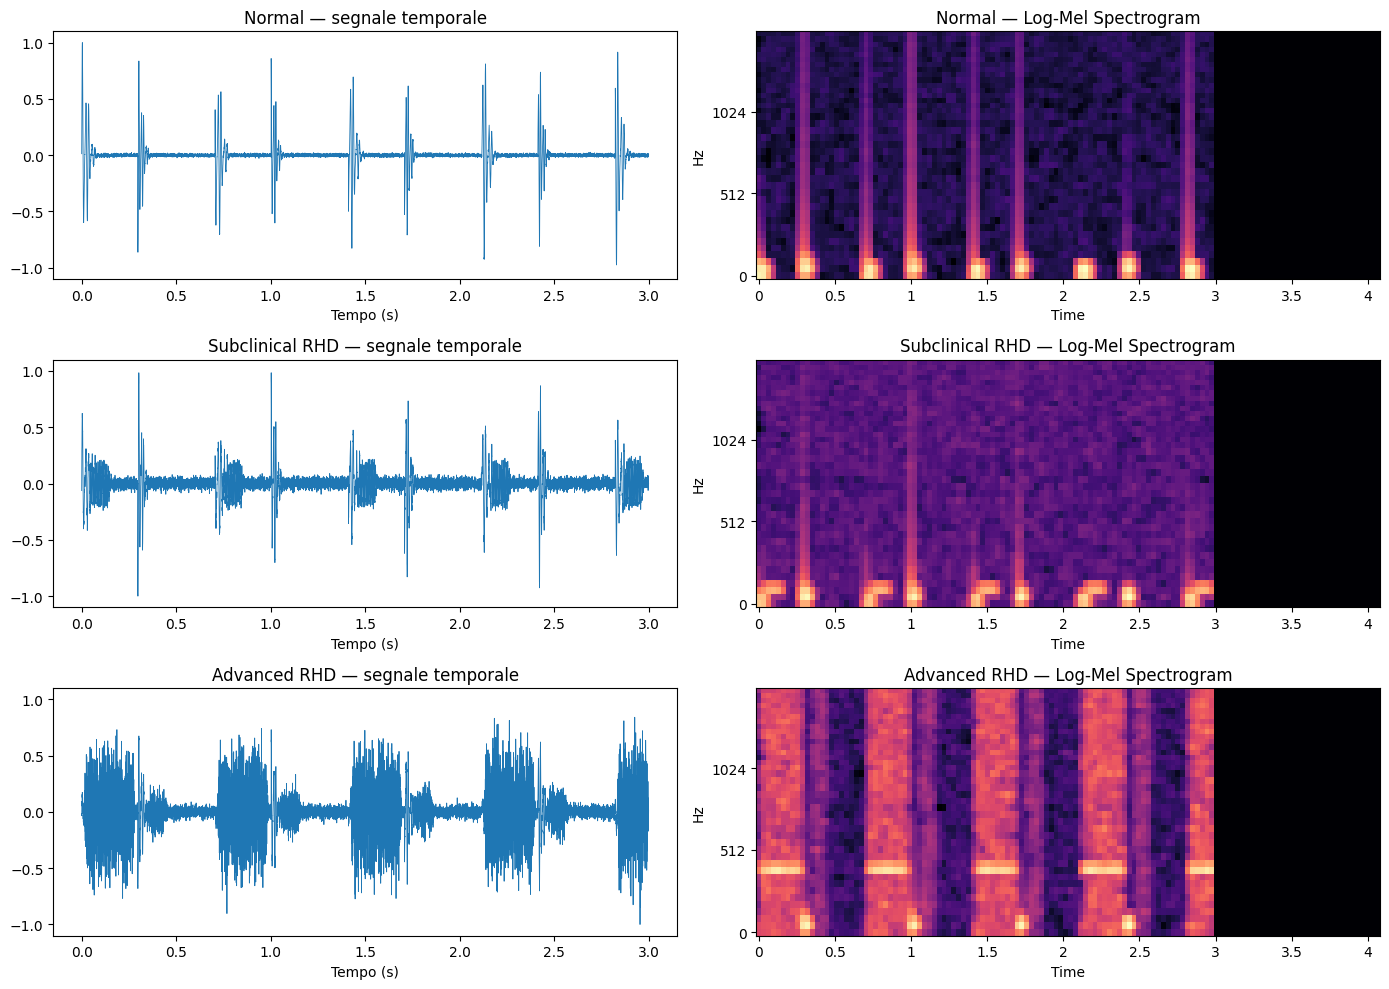


Train: 4200 | Val: 900 | Test: 900
Input shape per il modello: (40, 128, 1)
Class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0)}


In [10]:
# =====================================================================
# CELLA 4 — Generazione dataset completo
# 500 campioni base × 4 (1 originale + 3 aumentati) × 3 classi
# = 6000 campioni totali
# =====================================================================

N_PER_CLASS = 500
AUG_FACTOR  = 3

class_names = ['Normal', 'Subclinical RHD', 'Advanced RHD']
generators  = [
    generate_normal_pcg,
    generate_subclinical_pcg,
    generate_advanced_pcg,
]

X_list, y_list = [], []

for label, gen_fn in enumerate(generators):
    print(f"Generazione classe {label} ({class_names[label]})...")
    for i in tqdm(range(N_PER_CLASS)):
        hr  = np.random.randint(75, 110)
        sig = gen_fn(sr=SR, duration=3.0, heart_rate=hr, seed=i)
        sg  = pcg_to_melspec(sig)

        # Campione originale
        X_list.append(sg)
        y_list.append(label)

        # Versioni aumentate
        for _ in range(AUG_FACTOR):
            X_list.append(augment_spectrogram(sg))
            y_list.append(label)

X_all = np.array(X_list, dtype=np.float32)
y_all = np.array(y_list, dtype=np.int32)

print(f"\nDataset completo — shape: {X_all.shape}")
for i, name in enumerate(class_names):
    print(f"  Classe {i} ({name}): {np.sum(y_all == i)} campioni")

# ------------------------------------------------------------------
# Visualizzazione — confronto 3 classi
# ------------------------------------------------------------------

fig, axs = plt.subplots(3, 2, figsize=(14, 10))
fns = [generate_normal_pcg, generate_subclinical_pcg, generate_advanced_pcg]

for cls in range(3):
    sig = fns[cls](sr=SR, duration=3.0, heart_rate=85, seed=0)
    sg  = pcg_to_melspec(sig)

    axs[cls, 0].plot(np.linspace(0, 3, len(sig)), sig, linewidth=0.6)
    axs[cls, 0].set_title(f'{class_names[cls]} — segnale temporale')
    axs[cls, 0].set_xlabel('Tempo (s)')
    axs[cls, 0].set_ylim(-1.1, 1.1)

    librosa.display.specshow(sg, sr=SR, hop_length=HOP_LENGTH,
                             x_axis='time', y_axis='mel', ax=axs[cls, 1])
    axs[cls, 1].set_title(f'{class_names[cls]} — Log-Mel Spectrogram')

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# Preprocessing finale: normalizzazione + canale + split
# ------------------------------------------------------------------

X_all = X_all[..., np.newaxis]  # (N, n_mels, sg_maxlen, 1)

X_min = X_all.min()
X_max = X_all.max()
X_all = 2 * (X_all - X_min) / (X_max - X_min + 1e-8) - 1

X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all, test_size=0.30,
    stratify=y_all, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50,
    stratify=y_temp, random_state=42)

cw = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train)
class_weights = dict(enumerate(cw))

print(f"\nTrain: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")
print(f"Input shape per il modello: {X_train.shape[1:]}")
print(f"Class weights: {class_weights}")

SQI segnale processato: 0.735
Qualità accettabile: ✅ SI


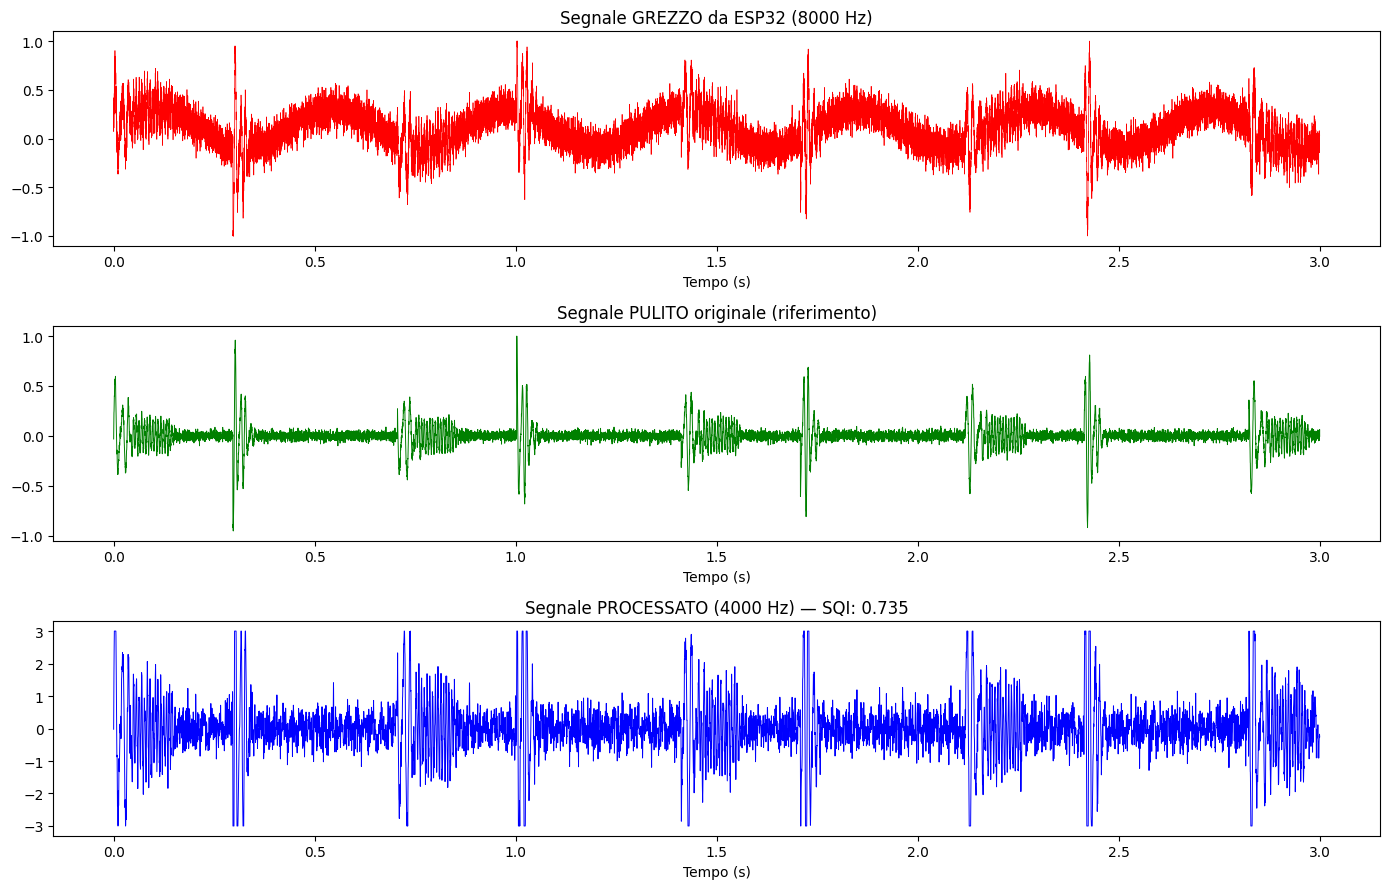

In [11]:
# =====================================================================
# CELLA 5 — Preprocessing segnale grezzo ESP32
# Questa è la funzione che userai in produzione con i WAV reali
# =====================================================================

from scipy.signal import butter, sosfiltfilt, decimate
from scipy.stats import kurtosis as sp_kurtosis


def simulate_raw_esp32_signal(clean_signal, sr_clean=SR, sr_raw=8000):
    """Simula il segnale grezzo come uscirebbe dall'ESP32."""
    np.random.seed(None)
    ratio     = sr_raw // sr_clean
    upsampled = np.repeat(clean_signal, ratio)
    n = len(upsampled)
    t = np.linspace(0, len(clean_signal)/sr_clean, n)

    dc_offset   = np.random.uniform(-0.15, 0.15)
    ambient     = np.random.randn(n) * np.random.uniform(0.05, 0.15)
    movement    = 0.2 * np.sin(2*np.pi*np.random.uniform(0.5, 3)*t)
    powerline   = np.random.uniform(0.02, 0.08) * np.sin(2*np.pi*50*t)

    raw = upsampled + dc_offset + ambient + movement + powerline
    raw = np.clip(raw, -1.0, 1.0)
    return raw.astype(np.float32), sr_raw


def preprocess_pcg(raw_signal, sr_raw=8000, sr_target=SR,
                   f_low=20, f_high=800, filter_order=6):
    """
    Pipeline completa di preprocessing:
    1. Decimazione 8000 → 4000 Hz
    2. Rimozione offset DC
    3. Filtro bandpass Butterworth 20-800 Hz (zero-phase)
    4. Normalizzazione z-score
    5. Clipping artefatti residui
    """
    # 1. Decimazione
    factor = sr_raw // sr_target
    signal = decimate(raw_signal, factor, ftype='fir', zero_phase=True)
    signal = signal.astype(np.float32)

    # 2. DC removal
    signal = signal - np.mean(signal)

    # 3. Filtro bandpass zero-phase
    nyq  = sr_target / 2.0
    sos  = butter(filter_order, [f_low/nyq, f_high/nyq],
                  btype='band', output='sos')
    signal = sosfiltfilt(sos, signal)

    # 4. Z-score normalizzazione
    std = np.std(signal)
    if std > 1e-8:
        signal = (signal - np.mean(signal)) / std

    # 5. Clipping artefatti (> 3 std)
    signal = np.clip(signal, -3.0, 3.0)

    return signal.astype(np.float32)


def compute_sqi(signal, sr=SR, f_low=20, f_high=800):
    """
    Signal Quality Index [0-1].
    Combina SNR stimato, kurtosis e stabilità ampiezza.
    Soglia consigliata: SQI > 0.4
    """
    from scipy.signal import welch

    freqs, psd   = welch(signal, fs=sr, nperseg=256)
    cardiac_mask = (freqs >= f_low) & (freqs <= f_high)
    noise_mask   = freqs > f_high

    cardiac_power = psd[cardiac_mask].mean() + 1e-10
    noise_power   = psd[noise_mask].mean()   + 1e-10
    snr_score     = np.clip(cardiac_power / noise_power / 10, 0, 1)

    kurt       = sp_kurtosis(signal)
    kurt_score = np.clip((kurt - 1) / 10, 0, 1)

    window_size = sr // 2
    n_windows   = len(signal) // window_size
    if n_windows > 1:
        energies  = [np.var(signal[i*window_size:(i+1)*window_size])
                     for i in range(n_windows)]
        stability = np.clip(
            1 - np.std(energies) / (np.mean(energies) + 1e-8), 0, 1)
    else:
        stability = 0.5

    return float(np.clip(0.5*snr_score + 0.3*kurt_score + 0.2*stability, 0, 1))


SQI_THRESHOLD = 0.4

# ------------------------------------------------------------------
# Test visivo della pipeline su un esempio
# ------------------------------------------------------------------

clean = generate_subclinical_pcg(sr=SR, duration=3.0,
                                  heart_rate=85, seed=42)
raw, sr_raw   = simulate_raw_esp32_signal(clean)
processed     = preprocess_pcg(raw, sr_raw=sr_raw, sr_target=SR)
sqi_processed = compute_sqi(processed)

print(f"SQI segnale processato: {sqi_processed:.3f}")
print(f"Qualità accettabile: {'✅ SI' if sqi_processed >= SQI_THRESHOLD else '❌ NO'}")

fig, axs = plt.subplots(3, 1, figsize=(14, 9))
t_raw  = np.linspace(0, len(raw)/sr_raw, len(raw))
t_proc = np.linspace(0, len(processed)/SR, len(processed))

axs[0].plot(t_raw, raw, linewidth=0.5, color='red')
axs[0].set_title('Segnale GREZZO da ESP32 (8000 Hz)')

axs[1].plot(t_proc, clean, linewidth=0.7, color='green')
axs[1].set_title('Segnale PULITO originale (riferimento)')

axs[2].plot(t_proc, processed, linewidth=0.7, color='blue')
axs[2].set_title(f'Segnale PROCESSATO (4000 Hz) — SQI: {sqi_processed:.3f}')

for ax in axs:
    ax.set_xlabel('Tempo (s)')
plt.tight_layout()
plt.show()


# Funzione end-to-end per produzione
def wav_to_input(wav_path=None, raw_signal=None, sr_raw=8000,
                 sr_target=SR, sqi_threshold=SQI_THRESHOLD):
    """
    WAV grezzo → input pronto per il modello.
    Restituisce (sg_input, sqi, processed) oppure (None, sqi, processed)
    se SQI < soglia.
    """
    import soundfile as sf
    if wav_path is not None:
        raw_signal, sr_raw = sf.read(wav_path)
        if raw_signal.ndim > 1:
            raw_signal = raw_signal[:, 0]
        raw_signal = raw_signal.astype(np.float32)

    processed = preprocess_pcg(raw_signal, sr_raw=sr_raw,
                                sr_target=sr_target)
    sqi = compute_sqi(processed, sr=sr_target)

    if sqi < sqi_threshold:
        print(f"⚠️  SQI = {sqi:.3f} — qualità insufficiente, ripetere")
        return None, sqi, processed

    sg       = pcg_to_melspec(processed, sr=sr_target)
    sg_input = sg[np.newaxis, ..., np.newaxis]
    sg_input = 2 * (sg_input - X_min) / (X_max - X_min + 1e-8) - 1
    return sg_input, sqi, processed

In [12]:
# =====================================================================
# CELLA 6 — Modello CNN + LSTM semplificato
# =====================================================================

def build_simple_cnn_lstm(input_shape, n_classes=3,
                           dropout=0.5, l2=1e-4):
    """
    Modello volutamente compatto:
    - Pochi parametri → meno overfitting su dataset piccolo
    - L2 regularisation su tutti i layer
    - Dropout aggressivo (0.5)
    """
    inp = layers.Input(shape=input_shape)

    # Blocco CNN 1
    x = layers.Conv2D(16, (3,3), padding='same',
                      kernel_regularizer=regularizers.l2(l2))(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.3)(x)

    # Blocco CNN 2
    x = layers.Conv2D(32, (3,3), padding='same',
                      kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.3)(x)

    # Reshape per LSTM: (batch, freq, time, ch) → (batch, time, freq*ch)
    sh = x.shape
    x  = layers.Permute((2,1,3))(x)
    x  = layers.Reshape((sh[2], sh[1]*sh[3]))(x)

    # LSTM
    x = layers.LSTM(32, kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.Dropout(dropout)(x)

    # Output
    x   = layers.Dense(32, activation='relu',
                        kernel_regularizer=regularizers.l2(l2))(x)
    x   = layers.Dropout(dropout)(x)
    out = layers.Dense(n_classes, activation='softmax')(x)

    return models.Model(inputs=inp, outputs=out, name='CNN_LSTM_RHD')


input_shape = X_train.shape[1:]
model       = build_simple_cnn_lstm(input_shape, n_classes=3)
model.summary()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Model: "CNN_LSTM_RHD"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 40, 128, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 40, 128, 16)    │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 40, 128, 16)    │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 40, 128, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 20, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 20, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 20, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 20, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ permute (Permute)               │ (None, 32, 10, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 32, 320)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │        45,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,331 (200.51 KB)

 Trainable params: 51,235 (200.14 KB)

 Non-trainable params: 96 (384.00 B)

In [13]:
# =====================================================================
# CELLA 7 — Training
# =====================================================================

EPOCHS     = 100
BATCH_SIZE = 64

cb_list = [
    callbacks.ModelCheckpoint(
        '/content/best_model.keras',
        monitor='val_loss', save_best_only=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=8, min_lr=1e-7, verbose=1
    ),
    callbacks.EarlyStopping(
        monitor='val_loss', patience=20,
        restore_best_weights=True, verbose=1
    )
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=cb_list
)
print("Training completato.")

Epoch 1/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 738ms/step - accuracy: 0.4174 - loss: 1.0960
Epoch 1: val_loss improved from None to 1.11396, saving model to /content/best_model.keras

Epoch 1: finished saving model to /content/best_model.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 61s 800ms/step - accuracy: 0.4843 - loss: 1.0123 - val_accuracy: 0.3356 - val_loss: 1.1140 - learning_rate: 1.0000e-04
Epoch 2/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 0.6404 - loss: 0.8176
Epoch 2: val_loss improved from 1.11396 to 1.10539, saving model to /content/best_model.keras

Epoch 2: finished saving model to /content/best_model.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 55s 408ms/step - accuracy: 0.6721 - loss: 0.7771 - val_accuracy: 0.3333 - val_loss: 1.1054 - learning_rate: 1.0000e-04
Epoch 3/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.7791 - loss: 0.5970
Epoch 3: val_loss did not improve from 1.10539
66/66 ━━━━━━━━━━━━━━━━━━━━ 41s 413ms/step - accuracy: 0.7950 - loss: 0.5674 - val_accuracy: 0

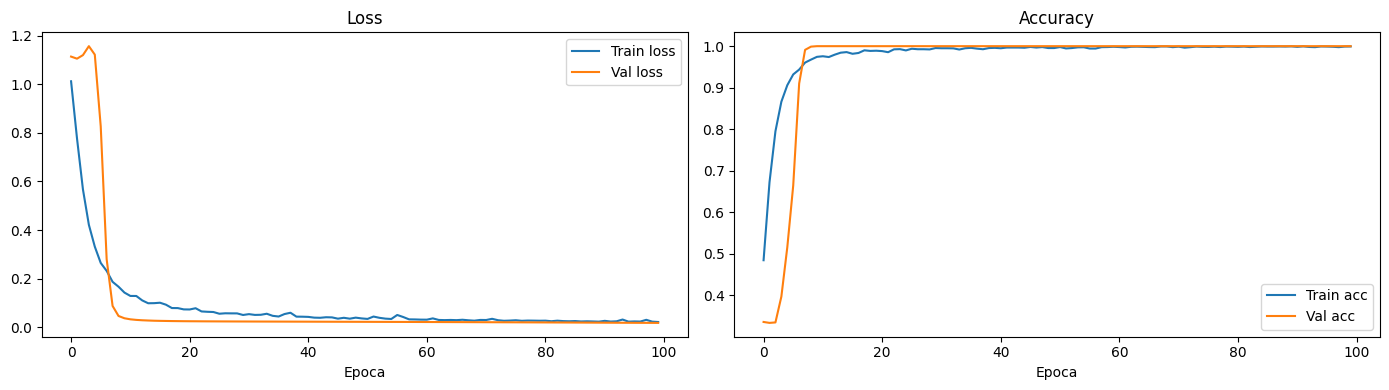

29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step

Classification Report:
                 precision    recall  f1-score   support

         Normal       1.00      1.00      1.00       300
Subclinical RHD       1.00      1.00      1.00       300
   Advanced RHD       1.00      1.00      1.00       300

       accuracy                           1.00       900
      macro avg       1.00      1.00      1.00       900
   weighted avg       1.00      1.00      1.00       900



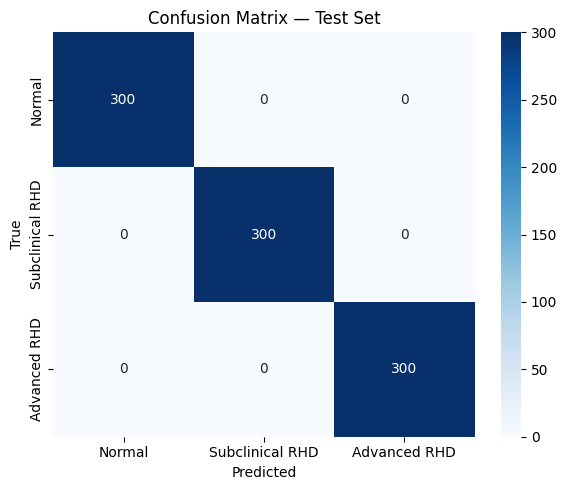


Sensitivity (macro):    1.000
Specificity per classe: {'Normal': '1.000', 'Subclinical RHD': '1.000', 'Advanced RHD': '1.000'}
Must-have target ≥0.85: ✅ PASS


In [14]:
# =====================================================================
# CELLA 8 — Valutazione e grafici
# =====================================================================

# Curve loss e accuracy
fig, axs = plt.subplots(1, 2, figsize=(14, 4))
axs[0].plot(history.history['loss'],     label='Train loss')
axs[0].plot(history.history['val_loss'], label='Val loss')
axs[0].set_title('Loss')
axs[0].set_xlabel('Epoca')
axs[0].legend()

axs[1].plot(history.history['accuracy'],     label='Train acc')
axs[1].plot(history.history['val_accuracy'], label='Val acc')
axs[1].set_title('Accuracy')
axs[1].set_xlabel('Epoca')
axs[1].legend()
plt.tight_layout()
plt.show()

# Valutazione test set
y_pred_prob = model.predict(X_test)
y_pred      = np.argmax(y_pred_prob, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.show()

# Metriche chiave
from sklearn.metrics import recall_score
sensitivity = recall_score(y_test, y_pred, average='macro')

specificity_per_class = []
for i in range(len(class_names)):
    tn = cm.sum() - (cm[i,:].sum() + cm[:,i].sum() - cm[i,i])
    fp = cm[:,i].sum() - cm[i,i]
    specificity_per_class.append(tn / (tn + fp + 1e-8))

print(f"\nSensitivity (macro):    {sensitivity:.3f}")
print(f"Specificity per classe: "
      f"{dict(zip(class_names, [f'{s:.3f}' for s in specificity_per_class]))}")
print(f"Must-have target ≥0.85: "
      f"{'✅ PASS' if sensitivity >= 0.85 else '❌ NON RAGGIUNTO'}")

In [15]:
# =====================================================================
# CELLA 9 — Conversione TFLite per deployment Android
# =====================================================================

best_model = tf.keras.models.load_model('/content/best_model.keras')

converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

def representative_dataset():
    for i in range(min(200, len(X_train))):
        yield [X_train[i:i+1].astype(np.float32)]

converter.representative_dataset  = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type   = tf.float32
converter.inference_output_type  = tf.float32

tflite_model = converter.convert()

tflite_path = '/content/rhd_model_int8.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

size_tflite = os.path.getsize(tflite_path) / 1e6
print(f"Modello TFLite INT8: {size_tflite:.2f} MB")
print(f"Salvato in: {tflite_path}")

# Salva X_min e X_max per la normalizzazione in produzione
np.save('/content/x_min.npy', X_min)
np.save('/content/x_max.npy', X_max)
print("x_min e x_max salvati.")

# Test inferenza TFLite su un campione
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()
inp_det  = interpreter.get_input_details()
out_det  = interpreter.get_output_details()

sample = X_test[0:1].astype(np.float32)
interpreter.set_tensor(inp_det[0]['index'], sample)
interpreter.invoke()
pred = interpreter.get_tensor(out_det[0]['index'])

print(f"\nTest inferenza TFLite:")
print(f"  Probabilità: {pred[0]}")
print(f"  Classe predetta: {class_names[np.argmax(pred[0])]}")
print(f"  Classe vera:     {class_names[y_test[0]]}")

Saved artifact at '/tmp/tmpd1msha8v'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 40, 128, 1), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  137658612446800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137658612436624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137658612448528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137658612449104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137658612439696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137658612432976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137658612433552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137658619268368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137658612440080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137658612439888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137658612437968:

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


ConverterError: <unknown>:0: error: loc(callsite(fused["TensorListReserve:", "CNN_LSTM_RHD_1/lstm_1/TensorArrayV2_1@__inference_function_57206"] at callsite(fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper_57293"] at fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"]))): 'tf.TensorListReserve' op requires element_shape to be static during TF Lite transformation pass
<unknown>:0: note: loc(callsite(fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper_57293"] at fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"])): called from
<unknown>:0: note: loc(fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"]): called from
<unknown>:0: error: loc(callsite(fused["TensorListReserve:", "CNN_LSTM_RHD_1/lstm_1/TensorArrayV2_1@__inference_function_57206"] at callsite(fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper_57293"] at fused["StatefulPartitionedCa